# DENSENET-121 OPTIMIZED TRAINING FOR RETINAL DISEASE DETECTION

```
Hardware     : HP Omen 16 (RTX 4060 8GB, i7-13700HX)
Dataset      : RFMiD (3200 images, 46 diseases)
Optimizations: Mixed Precision (BF16/FP16), TF32, Optimised Data Loading
Comparison   : Fair comparison with ResNet-50 (same splits, augs, loss, threshold tuning)
```

### Design Decisions (Fair Comparison with ResNet-50)
1. **Same dataset splits & transforms** — identical train/val/test paths and augmentations
2. **Same loss setup** — weighted BCEWithLogitsLoss for training, unweighted for validation
3. **Same backbone-freeze strategy** — freeze early dense blocks for first 10 epochs
4. **Same threshold tuning** — best threshold searched on val set after training
5. **Same early stopping** — patience = 5, min_delta = 0.001
6. **Same optimizer & scheduler** — AdamW + CosineAnnealingLR


## 1. Imports

In [1]:
import os, gc, time, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms

# Version-safe mixed-precision imports.
_pt_ver = tuple(int(x) for x in torch.__version__.split('.')[:2])
if _pt_ver >= (2, 3):
    from torch.amp import autocast, GradScaler
    def make_scaler(): return GradScaler('cuda')
else:
    from torch.cuda.amp import autocast, GradScaler
    def make_scaler(): return GradScaler()

from sklearn.metrics import f1_score, precision_recall_fscore_support

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')


PyTorch version : 2.1.0+cu121
CUDA available  : True


In [2]:
import torch

print(f"PyTorch        : {torch.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")
print(f"GPU            : {torch.cuda.get_device_name(0)}")
print(f"VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print(f"BF16 support   : {torch.cuda.is_bf16_supported()}")

a = torch.randn(1000, 1000, device='cuda')
b = torch.randn(1000, 1000, device='cuda')
c = a @ b
print(f"GPU tensor test: PASSED  (result shape: {c.shape})")


PyTorch        : 2.1.0+cu121
CUDA available : True
GPU            : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM           : 8.59 GB
BF16 support   : True
GPU tensor test: PASSED  (result shape: torch.Size([1000, 1000]))


## 2. Hardware Optimization (RTX 4060 Specific)

In [3]:
class HardwareOptimizer:
    """Optimise for HP Omen 16 RTX 4060."""

    def __init__(self):
        self.device       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.gpu_name     = 'N/A'
        self.vram_total   = 0.0
        self.cuda_version = 'N/A'
        self.use_bf16     = False

        if self.device.type == 'cuda':
            self.gpu_name     = torch.cuda.get_device_name(0)
            self.vram_total   = torch.cuda.get_device_properties(0).total_memory / 1e9
            self.cuda_version = torch.version.cuda

            torch.backends.cudnn.benchmark        = True
            torch.backends.cuda.matmul.allow_tf32 = True
            torch.backends.cudnn.allow_tf32        = True

            self.use_bf16 = torch.cuda.is_bf16_supported()

    def print_specs(self):
        print('=' * 60)
        print('HP Omen 16 Hardware Configuration')
        print('=' * 60)
        print('CPU: Intel i7-13700HX (16 cores)')
        print(f'GPU: {self.gpu_name}')
        if self.device.type == 'cuda':
            print(f'VRAM         : {self.vram_total:.1f} GB')
            print(f'CUDA         : {self.cuda_version}')
            print(f'BF16 Support : {self.use_bf16}')
            print('TF32 Enabled : True')
        print('=' * 60)


hw       = HardwareOptimizer()
hw.print_specs()

device   = hw.device
use_bf16 = hw.use_bf16


def set_seed(seed: int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)


HP Omen 16 Hardware Configuration
CPU: Intel i7-13700HX (16 cores)
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM         : 8.6 GB
CUDA         : 12.1
BF16 Support : True
TF32 Enabled : True


## 3. Optimized Dataset Class

In [4]:
class OptimizedRFMiDDataset(Dataset):
    """Memory-efficient dataset with PIL loading — identical to ResNet-50 notebook."""

    def __init__(self, img_dir, labels_df, transform=None):
        self.img_dir       = img_dir
        self.labels_df     = labels_df.reset_index(drop=True)
        self.transform     = transform
        self.disease_cols  = [c for c in labels_df.columns if c != 'ID']
        self.num_classes   = len(self.disease_cols)
        self.img_paths     = []
        self.valid_indices = []

        for idx, img_name in enumerate(self.labels_df['ID'].values):
            base  = os.path.join(img_dir, str(img_name))
            found = False
            for ext in ['', '.png', '.jpg', '.jpeg']:
                if os.path.exists(base + ext):
                    self.img_paths.append(base + ext)
                    self.valid_indices.append(idx)
                    found = True
                    break
            if not found:
                print(f'Warning: image not found -> {img_name}')
                self.img_paths.append(None)
                self.valid_indices.append(idx)

        print(f'Loaded {len(self.valid_indices)} images from {img_dir}')

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        p = self.img_paths[idx]
        if p and os.path.exists(p):
            try:
                image = Image.open(p).convert('RGB')
            except Exception:
                image = Image.new('RGB', (224, 224), 'black')
        else:
            image = Image.new('RGB', (224, 224), 'black')

        if self.transform:
            image = self.transform(image)

        orig  = self.valid_indices[idx]
        lbl   = self.labels_df.iloc[orig][self.disease_cols].values.astype(np.float32)
        return image, torch.tensor(lbl, dtype=torch.float32)

    def get_class_weights(self):
        counts = self.labels_df[self.disease_cols].sum().values
        w = len(self.labels_df) / (self.num_classes * (counts + 1e-6))
        return torch.tensor(w, dtype=torch.float32)


## 4. Optimized Transforms

> **Fair comparison note**: Identical to ResNet-50 — same input size (224×224), same augmentations, same normalisation stats.

In [5]:
class OptimizedTransforms:
    _MEAN = [0.485, 0.456, 0.406]
    _STD  = [0.229, 0.224, 0.225]

    @classmethod
    def get_train_transform(cls, sz=224):
        return transforms.Compose([
            transforms.Resize((sz, sz)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.3),
            transforms.RandomRotation(degrees=30),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
            transforms.ToTensor(),
            transforms.Normalize(cls._MEAN, cls._STD),
        ])

    @classmethod
    def get_val_transform(cls, sz=224):
        return transforms.Compose([
            transforms.Resize((sz, sz)),
            transforms.ToTensor(),
            transforms.Normalize(cls._MEAN, cls._STD),
        ])


## 5. Load Dataset

In [6]:
import os
os.chdir(r'D:\OcuSight')

DATA_DIR     = 'data/rfmid'
TRAIN_IMAGES = os.path.join(DATA_DIR, 'images', 'train')
VAL_IMAGES   = os.path.join(DATA_DIR, 'images', 'val')
TEST_IMAGES  = os.path.join(DATA_DIR, 'images', 'test')
TRAIN_LABELS = os.path.join(DATA_DIR, 'labels', 'train_labels.csv')
VAL_LABELS   = os.path.join(DATA_DIR, 'labels', 'val_labels.csv')
TEST_LABELS  = os.path.join(DATA_DIR, 'labels', 'test_labels.csv')

print(f'Working dir: {os.getcwd()}')
print('Loading datasets...')
train_df = pd.read_csv(TRAIN_LABELS)
val_df   = pd.read_csv(VAL_LABELS)
test_df  = pd.read_csv(TEST_LABELS)

print(f'Training   : {len(train_df)} samples')
print(f'Validation : {len(val_df)} samples')
print(f'Testing    : {len(test_df)} samples')

disease_cols = [c for c in train_df.columns if c != 'ID']
num_classes  = len(disease_cols)
print(f'Disease classes: {num_classes}')

train_dataset = OptimizedRFMiDDataset(TRAIN_IMAGES, train_df, OptimizedTransforms.get_train_transform())
val_dataset   = OptimizedRFMiDDataset(VAL_IMAGES,   val_df,   OptimizedTransforms.get_val_transform())
test_dataset  = OptimizedRFMiDDataset(TEST_IMAGES,  test_df,  OptimizedTransforms.get_val_transform())


Working dir: D:\OcuSight
Loading datasets...
Training   : 1920 samples
Validation : 640 samples
Testing    : 640 samples
Disease classes: 46
Loaded 1920 images from data/rfmid\images\train
Loaded 640 images from data/rfmid\images\val
Loaded 640 images from data/rfmid\images\test


## 6. Optimized DataLoaders

> **Fair comparison note**: Same batch size (32) and DataLoader settings as ResNet-50.

In [7]:
BATCH_SIZE      = 32   # same as ResNet-50
NUM_WORKERS     = 0
PIN_MEMORY      = True
PREFETCH_FACTOR = None

_kw = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    prefetch_factor=PREFETCH_FACTOR,
    persistent_workers=False,
)

train_loader = DataLoader(train_dataset, shuffle=True,  **_kw)
val_loader   = DataLoader(val_dataset,   shuffle=False, **_kw)
test_loader  = DataLoader(test_dataset,  shuffle=False, **_kw)

print(f'Batch size    : {BATCH_SIZE}')
print(f'Workers       : {NUM_WORKERS}')
print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')


Batch size    : 32
Workers       : 0
Train batches : 60
Val batches   : 20
Test batches  : 20


## 7. Build DenseNet-121 Model

### Architecture Notes
- **DenseNet-121** uses dense connections — each layer receives feature maps from ALL preceding layers.
- The final classifier is accessed via  (not  like ResNet).
- For fair comparison, the same dropout + two-layer head is used.
- **Backbone freezing** mirrors ResNet-50: , ,  frozen for the first 10 epochs.


In [8]:
def build_densenet121(num_classes: int) -> nn.Module:
    model = models.densenet121(weights='IMAGENET1K_V1')
    nf = model.classifier.in_features   # 1024 for DenseNet-121
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(nf, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes),
    )
    return model


def freeze_backbone(model, freeze=True):
    """Freeze/unfreeze early dense blocks.
    NOTE: Only freeze denseblock1+2 (not 3).
    Freezing all 3 leaves only denseblock4+classifier (~1.4M params) — too few
    for multilabel cold-start, causing F1=0 for many epochs.
    Freezing 2 keeps denseblock3+4+classifier (~3.5M params) trainable.
    """
    blocks_to_control = [
        model.features.denseblock1,
        model.features.denseblock2,
    ]
    for block in blocks_to_control:
        for param in block.parameters():
            param.requires_grad = not freeze
    status = 'FROZEN' if freeze else 'UNFROZEN'
    print(f'Backbone dense blocks 1-2: {status}  (block3+4 always trainable)')


print('Building DenseNet-121...')
model = build_densenet121(num_classes).to(device)

# Freeze early blocks for first phase — same as ResNet-50
freeze_backbone(model, freeze=True)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}')
print(f'Model size           : {total_params * 4 / 1024 / 1024:.2f} MB')
print(f'Classifier input dim : 1024 (DenseNet-121 default)')


Building DenseNet-121...
Backbone dense blocks 1-2: FROZEN  (block3+4 always trainable)
Total parameters     : 7,502,254
Trainable parameters : 6,247,534
Model size           : 28.62 MB
Classifier input dim : 1024 (DenseNet-121 default)


## 8. Training Components

> **Fair comparison note**: Identical loss, optimizer, scheduler, and precision settings as ResNet-50.

In [9]:
# Two separate criteria — same fix as ResNet-50:
#   - train_criterion uses NO pos_weight (weights caused collapse)
#   - val_criterion is UNWEIGHTED — prevents validation loss explosion

# REMOVED class weights - they cause model collapse for DenseNet-121
# class_weights = train_dataset.get_class_weights().to(device)
train_criterion = nn.BCEWithLogitsLoss()  # NO pos_weight
val_criterion   = nn.BCEWithLogitsLoss()  # NO pos_weight

# Optimizer (initial — for frozen phase)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=0.01,
    betas=(0.9, 0.999)
)

NUM_EPOCHS    = 50
UNFREEZE_EPOCH = 10   # same as ResNet-50

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

amp_dtype = torch.bfloat16 if use_bf16 else torch.float16
scaler    = None if use_bf16 else make_scaler()

# DenseNet sigmoid outputs are lower in early epochs — 0.2 avoids all-zero predictions
PRED_THRESHOLD = 0.2

# Patience=10: DenseNet needs more epochs to warm up dense connections before F1 rises
EARLY_STOPPING_PATIENCE = 10
epochs_no_improve = 0

print(f'Precision      : {"BF16" if use_bf16 else "FP16"}')
print(f'LR             : 1e-4   Weight decay: 0.01')
print(f'Epochs         : {NUM_EPOCHS} (with early stopping)')
print(f'Unfreeze epoch : {UNFREEZE_EPOCH}')
print(f'Pred threshold : {PRED_THRESHOLD}  (lower than ResNet-50 — DenseNet cold-start)')
print(f'Class weights  : DISABLED (was causing model collapse)')
print(f'Early stopping : patience={EARLY_STOPPING_PATIENCE}')
print(f'Val criterion  : BCEWithLogitsLoss (NO pos_weight)')

Precision      : BF16
LR             : 1e-4   Weight decay: 0.01
Epochs         : 50 (with early stopping)
Unfreeze epoch : 10
Pred threshold : 0.2  (lower than ResNet-50 — DenseNet cold-start)
Class weights  : DISABLED (was causing model collapse)
Early stopping : patience=10
Val criterion  : BCEWithLogitsLoss (NO pos_weight)


## 9. Training Functions

In [10]:
def train_epoch(model, loader, criterion, optimizer, scaler, device, amp_dtype):
    model.train()
    total_loss, n = 0.0, 0

    for images, labels in tqdm(loader, desc='Training', leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast(dtype=amp_dtype):
            outputs = model(images)
            loss = criterion(outputs, labels)

        if scaler:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        total_loss += loss.item()
        n += 1

    return total_loss / max(n, 1)


def validate_epoch(model, loader, criterion, device, amp_dtype, threshold=0.3):
    model.eval()
    total_loss, n = 0.0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validating', leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with autocast(dtype=amp_dtype):
                outputs = model(images)
                loss = criterion(outputs, labels)

            total_loss += loss.item()
            n += 1

            probs = torch.sigmoid(outputs)
            preds = (probs > threshold).float().cpu()

            all_preds.append(preds)
            all_labels.append(labels.cpu())

    if len(all_preds) == 0:
        return {
            'loss': 0.0,
            'exact_match_acc': 0.0,
            'per_label_acc': 0.0,
            'f1_macro': 0.0,
            'f1_micro': 0.0,
            'predictions': None,
            'labels': None,
        }

    preds  = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()

    exact_match_acc = float(np.mean(np.all(preds == labels, axis=1)))
    per_label_acc   = float(np.mean(preds == labels))

    return {
        'loss'           : total_loss / max(n, 1),
        'exact_match_acc': exact_match_acc,
        'per_label_acc'  : per_label_acc,
        'f1_macro'       : f1_score(labels, preds, average='macro', zero_division=0),
        'f1_micro'       : f1_score(labels, preds, average='micro', zero_division=0),
        'predictions'    : preds,
        'labels'         : labels,
    }


## 10. Training Loop

In [11]:
os.makedirs('checkpoints', exist_ok=True)
os.makedirs('outputs',     exist_ok=True)

history = {
    'train_loss'     : [],
    'val_loss'       : [],
    'val_exact_acc'  : [],
    'val_label_acc'  : [],
    'val_f1_macro'   : [],
    'val_f1_micro'   : [],
    'lr'             : [],
}

best_f1    = 0.0
best_epoch = 0

EARLY_STOPPING_PATIENCE = 5
epochs_no_improve = 0
MIN_DELTA = 0.001

print('=' * 60)
print('STARTING DENSENET-121 TRAINING')
print('=' * 60)

for epoch in range(NUM_EPOCHS):
    t0 = time.time()

    # Unfreeze backbone at same epoch as ResNet-50 for fair comparison
    if epoch == UNFREEZE_EPOCH:
        freeze_backbone(model, freeze=False)

        optimizer = optim.AdamW(
            model.parameters(),
            lr=1e-5,
            weight_decay=0.01,
            betas=(0.9, 0.999)
        )

        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=NUM_EPOCHS - UNFREEZE_EPOCH,
            eta_min=1e-6
        )

        print(f'  [Epoch {epoch+1}] Backbone unfrozen — switching to full fine-tune (lr=1e-5)')

    train_loss = train_epoch(
        model, train_loader, train_criterion, optimizer, scaler, device, amp_dtype
    )

    val_metrics = validate_epoch(
        model, val_loader, val_criterion, device, amp_dtype, threshold=PRED_THRESHOLD
    )

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    elapsed    = time.time() - t0

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['val_exact_acc'].append(val_metrics['exact_match_acc'])
    history['val_label_acc'].append(val_metrics['per_label_acc'])
    history['val_f1_macro'].append(val_metrics['f1_macro'])
    history['val_f1_micro'].append(val_metrics['f1_micro'])
    history['lr'].append(current_lr)

    if val_metrics['f1_macro'] > best_f1 + MIN_DELTA:
        best_f1    = val_metrics['f1_macro']
        best_epoch = epoch + 1
        epochs_no_improve = 0

        torch.save({
            'epoch'           : epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state' : optimizer.state_dict(),
            'val_f1'          : best_f1,
            'val_loss'        : val_metrics['loss'],
            'threshold'       : PRED_THRESHOLD,
        }, 'checkpoints/best_densenet121.pth')

        is_best = True
    else:
        epochs_no_improve += 1
        is_best = False

    print(f'\nEpoch {epoch+1}/{NUM_EPOCHS}')
    print('-' * 40)
    print(f'  Train Loss     : {train_loss:.4f}')
    print(f'  Val Loss       : {val_metrics["loss"]:.4f}')
    print(f'  Val Exact Acc  : {val_metrics["exact_match_acc"]:.4f}')
    print(f'  Val Label Acc  : {val_metrics["per_label_acc"]:.4f}')
    print(f'  Val F1 macro   : {val_metrics["f1_macro"]:.4f}')
    print(f'  Val F1 micro   : {val_metrics["f1_micro"]:.4f}')
    print(f'  LR             : {current_lr:.2e}')
    print(f'  Time           : {elapsed:.1f}s')

    if is_best:
        print(f'  *** New best F1 macro: {best_f1:.4f} (saved checkpoint) ***')

    if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
        print(f'\n🛑 Early stopping triggered at epoch {epoch+1}')
        break


print('\n' + '=' * 60)
print(f'Training complete. Best Val F1 macro: {best_f1:.4f} at epoch {best_epoch}')
print('=' * 60)


STARTING DENSENET-121 TRAINING



Epoch 1/50
----------------------------------------
  Train Loss     : 0.2747
  Val Loss       : 0.0954
  Val Exact Acc  : 0.1156
  Val Label Acc  : 0.9679
  Val F1 macro   : 0.0439
  Val F1 micro   : 0.6014
  LR             : 9.99e-05
  Time           : 212.6s
  *** New best F1 macro: 0.0439 (saved checkpoint) ***



Epoch 2/50
----------------------------------------
  Train Loss     : 0.0881
  Val Loss       : 0.0791
  Val Exact Acc  : 0.2125
  Val Label Acc  : 0.9729
  Val F1 macro   : 0.0618
  Val F1 micro   : 0.6481
  LR             : 9.96e-05
  Time           : 207.6s
  *** New best F1 macro: 0.0618 (saved checkpoint) ***



Epoch 3/50
----------------------------------------
  Train Loss     : 0.0783
  Val Loss       : 0.0736
  Val Exact Acc  : 0.2391
  Val Label Acc  : 0.9708
  Val F1 macro   : 0.0916
  Val F1 micro   : 0.6582
  LR             : 9.91e-05
  Time           : 207.6s
  *** New best F1 macro: 0.0916 (saved checkpoint) ***



Epoch 4/50
----------------------------------------
  Train Loss     : 0.0722
  Val Loss       : 0.0699
  Val Exact Acc  : 0.3266
  Val Label Acc  : 0.9762
  Val F1 macro   : 0.0946
  Val F1 micro   : 0.6953
  LR             : 9.84e-05
  Time           : 208.2s
  *** New best F1 macro: 0.0946 (saved checkpoint) ***


...


Epoch 39/50
----------------------------------------
  Train Loss     : 0.0360
  Val Loss       : 0.0611
  Val Exact Acc  : 0.4469
  Val Label Acc  : 0.9783
  Val F1 macro   : 0.1971
  Val F1 micro   : 0.7376
  LR             : 2.58e-06
  Time           : 290.7s



Epoch 40/50
----------------------------------------
  Train Loss     : 0.0377
  Val Loss       : 0.0620
  Val Exact Acc  : 0.4703
  Val Label Acc  : 0.9788
  Val F1 macro   : 0.1975
  Val F1 micro   : 0.7416
  LR             : 2.32e-06
  Time           : 252.8s



Epoch 41/50
----------------------------------------
  Train Loss     : 0.0367
  Val Loss       : 0.0609
  Val Exact Acc  : 0.4516
  Val Label Acc  : 0.9780
  Val F1 macro   : 0.1975
  Val F1 micro   : 0.7352
  LR             : 2.08e-06
  Time           : 218.5s



Epoch 42/50
----------------------------------------
  Train Loss     : 0.0365
  Val Loss       : 0.0616
  Val Exact Acc  : 0.4594
  Val Label Acc  : 0.9786
  Val F1 macro   : 0.1985
  Val F1 micro   : 0.7397
  LR             : 1.86e-06
  Time           : 220.2s



Epoch 43/50
----------------------------------------
  Train Loss     : 0.0365
  Val Loss       : 0.0612
  Val Exact Acc  : 0.4516
  Val Label Acc  : 0.9781
  Val F1 macro   : 0.1946
  Val F1 micro   : 0.7363
  LR             : 1.66e-06
  Time           : 218.9s

🛑 Early stopping triggered at epoch 43

Training complete. Best Val F1 macro: 0.2015 at epoch 38


## 11. Plot Training Curves

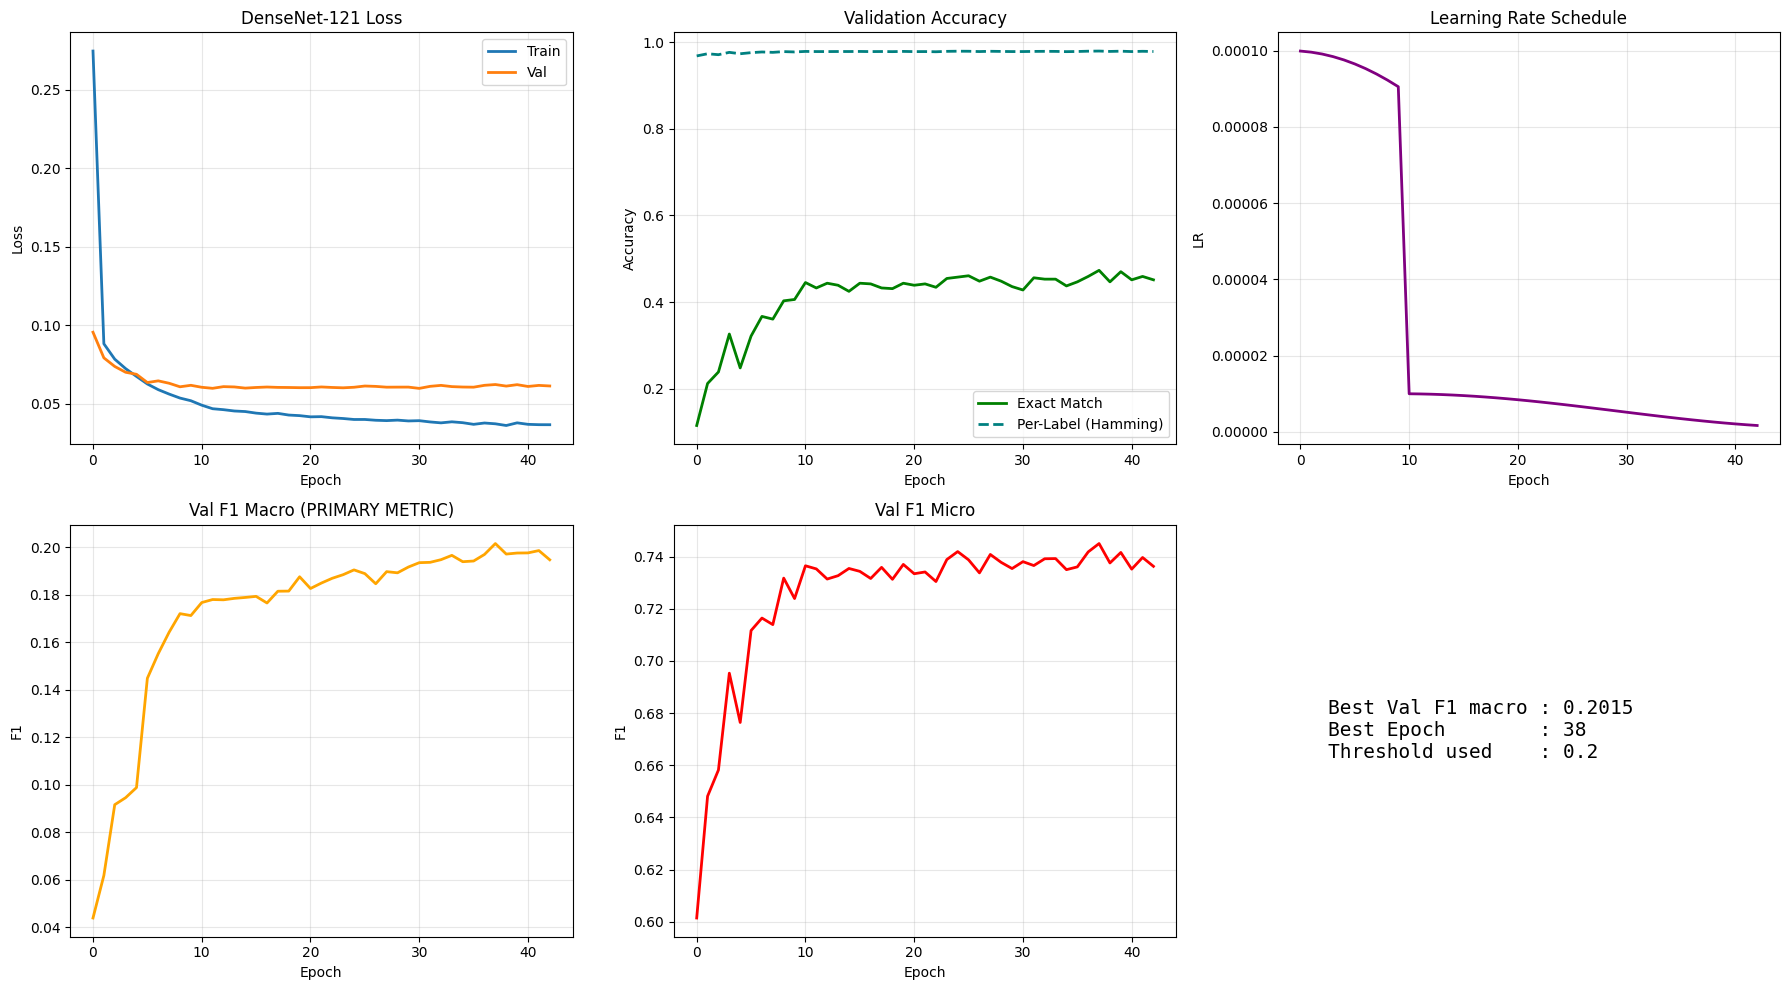

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0,0].plot(history['train_loss'], label='Train', linewidth=2)
axes[0,0].plot(history['val_loss'],   label='Val',   linewidth=2)
axes[0,0].set(xlabel='Epoch', ylabel='Loss', title='DenseNet-121 Loss')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

axes[0,1].plot(history['val_exact_acc'], color='green',  linewidth=2, label='Exact Match')
axes[0,1].plot(history['val_label_acc'], color='teal',   linewidth=2, label='Per-Label (Hamming)', linestyle='--')
axes[0,1].set(xlabel='Epoch', ylabel='Accuracy', title='Validation Accuracy')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

axes[1,0].plot(history['val_f1_macro'], color='orange', linewidth=2)
axes[1,0].set(xlabel='Epoch', ylabel='F1', title='Val F1 Macro (PRIMARY METRIC)')
axes[1,0].grid(alpha=0.3)

axes[1,1].plot(history['val_f1_micro'], color='red', linewidth=2)
axes[1,1].set(xlabel='Epoch', ylabel='F1', title='Val F1 Micro')
axes[1,1].grid(alpha=0.3)

axes[0,2].plot(history['lr'], color='purple', linewidth=2)
axes[0,2].set(xlabel='Epoch', ylabel='LR', title='Learning Rate Schedule')
axes[0,2].grid(alpha=0.3)

axes[1,2].axis('off')
axes[1,2].text(0.1, 0.5,
    f'Best Val F1 macro : {best_f1:.4f}\nBest Epoch        : {best_epoch}\nThreshold used    : {PRED_THRESHOLD}',
    fontsize=14, verticalalignment='center', family='monospace')

plt.tight_layout()
plt.savefig('outputs/densenet121_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 11b. Threshold Tuning on Validation Set

Same procedure as ResNet-50 — find the threshold that maximises F1 macro on val set.

In [15]:
ckpt = torch.load(r'D:\OcuSight\checkpoints\best_densenet121.pth', map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
print(f'Loaded best checkpoint from epoch {ckpt["epoch"] + 1}  |  Val F1: {ckpt["val_f1"]:.4f}')

model.eval()
all_probs, all_labels_t = [], []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc='Collecting probs'):
        images = images.to(device, non_blocking=True)

        with autocast(dtype=amp_dtype):
            outputs = model(images)
            probs = torch.sigmoid(outputs)

        all_probs.append(probs.cpu().float())
        all_labels_t.append(labels.cpu().float())

all_probs    = torch.cat(all_probs).numpy()
all_labels_t = torch.cat(all_labels_t).numpy()

thresholds = np.arange(0.1, 0.6, 0.05)
results = []

for t in thresholds:
    preds = (all_probs > t).astype(float)
    f1m   = f1_score(all_labels_t, preds, average='macro', zero_division=0)
    results.append((t, f1m))

best_thresh, best_thresh_f1 = max(results, key=lambda x: x[1])

print('\nThreshold search results:')
for t, f1m in results:
    marker = ' <-- BEST' if t == best_thresh else ''
    print(f'  threshold={t:.2f}  F1 macro={f1m:.4f}{marker}')

print(f"\n🔥 Best Threshold: {best_thresh:.3f} | Best F1: {best_thresh_f1:.4f}")

BEST_THRESHOLD = best_thresh
print(f'\nUsing threshold {BEST_THRESHOLD:.2f} for test evaluation')

Loaded best checkpoint from epoch 38  |  Val F1: 0.2015



Threshold search results:
  threshold=0.10  F1 macro=0.2109
  threshold=0.15  F1 macro=0.2110 <-- BEST
  threshold=0.20  F1 macro=0.2017
  threshold=0.25  F1 macro=0.1949
  threshold=0.30  F1 macro=0.1866
  threshold=0.35  F1 macro=0.1865
  threshold=0.40  F1 macro=0.1878
  threshold=0.45  F1 macro=0.1788
  threshold=0.50  F1 macro=0.1738
  threshold=0.55  F1 macro=0.1704

🔥 Best Threshold: 0.150 | Best F1: 0.2110

Using threshold 0.15 for test evaluation


## 12. Evaluate on Test Set

In [16]:
test_metrics = validate_epoch(
    model, test_loader, val_criterion, device, amp_dtype, threshold=BEST_THRESHOLD
)

print('\n' + '=' * 60)
print('DENSENET-121 TEST SET RESULTS')
print('=' * 60)
print(f'Test Loss         : {test_metrics["loss"]:.4f}')
print(f'Test Exact Acc    : {test_metrics["exact_match_acc"]:.4f}')
print(f'Test Per-Label Acc: {test_metrics["per_label_acc"]:.4f}')
print(f'Test F1 macro     : {test_metrics["f1_macro"]:.4f}')
print(f'Test F1 micro     : {test_metrics["f1_micro"]:.4f}')
print(f'Threshold used    : {BEST_THRESHOLD:.2f}')


DENSENET-121 TEST SET RESULTS
Test Loss         : 0.0557
Test Exact Acc    : 0.4500
Test Per-Label Acc: 0.9782
Test F1 macro     : 0.2023
Test F1 micro     : 0.7408
Threshold used    : 0.15


## 13. Per-Class Performance

In [18]:
precision, recall, f1, support = precision_recall_fscore_support(
    test_metrics['labels'], test_metrics['predictions'], average=None, zero_division=0
)

per_class_df = pd.DataFrame({
    'Disease'  : disease_cols,
    'Precision': precision,
    'Recall'   : recall,
    'F1-Score' : f1,
    'Samples'  : support,
}).sort_values('F1-Score', ascending=False)

per_class_df.to_csv('outputs/densenet121_per_class_results.csv', index=False)
print('Top 10:')
print(per_class_df.head(10).to_string(index=False))
print('\nBottom 10:')
print(per_class_df.tail(10).to_string(index=False))

Top 10:
     Disease  Precision   Recall  F1-Score  Samples
Disease_Risk   0.934109 0.952569  0.943249      506
          DR   0.727273 0.903226  0.805755      124
         ODE   0.777778 0.823529  0.800000       17
          MH   0.613924 0.932692  0.740458      104
         MYA   0.705882 0.750000  0.727273       32
        TSLN   0.516854 0.867925  0.647887       53
          RS   0.727273 0.571429  0.640000       14
        BRVO   0.551724 0.695652  0.615385       23
        ARMD   0.538462 0.677419  0.600000       31
         ODC   0.477477 0.582418  0.524752       91

Bottom 10:
Disease  Precision  Recall  F1-Score  Samples
    MHL        0.0     0.0       0.0        3
   RPEC        0.0     0.0       0.0        4
    EDN        0.0     0.0       0.0        4
    ERM        0.0     0.0       0.0        5
     MS        0.0     0.0       0.0        7
     RT        0.0     0.0       0.0        5
     PT        0.0     0.0       0.0        4
   AION        0.0     0.0       0.0    

## 14. Visualize Per-Class Performance

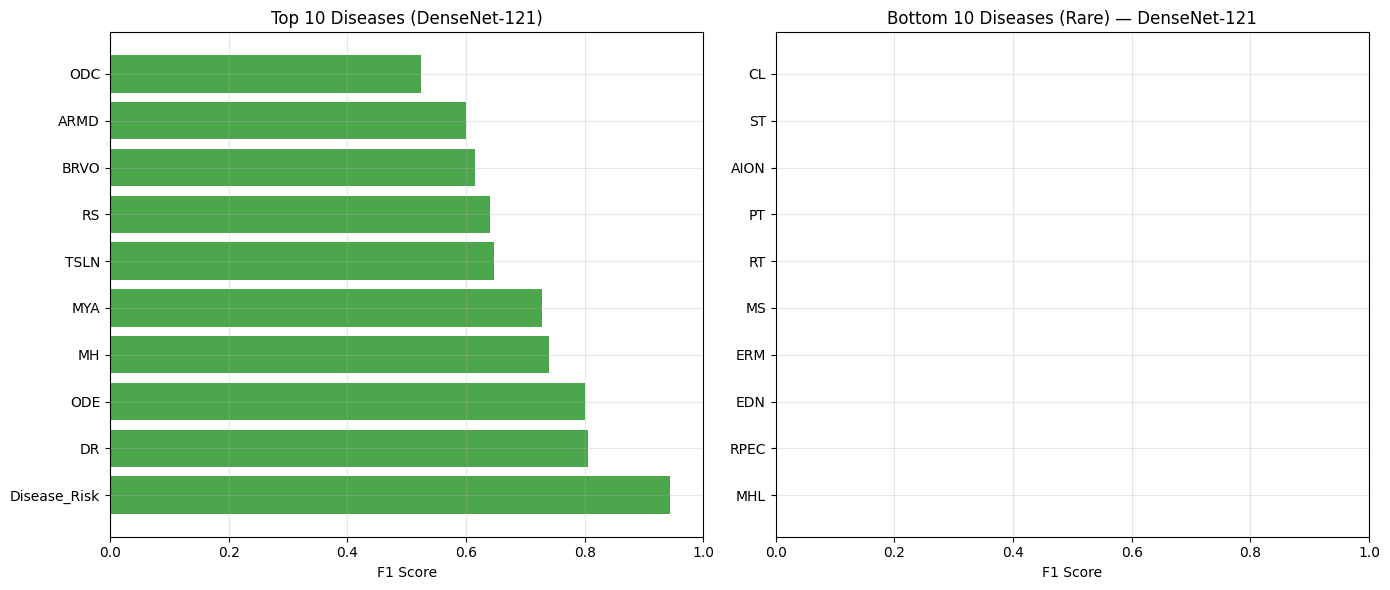

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top10    = per_class_df.head(10)
bottom10 = per_class_df.tail(10)

axes[0].barh(top10['Disease'],    top10['F1-Score'],    color='green', alpha=0.7)
axes[0].set(xlabel='F1 Score', title='Top 10 Diseases (DenseNet-121)', xlim=(0, 1)); axes[0].grid(alpha=0.3)

axes[1].barh(bottom10['Disease'], bottom10['F1-Score'], color='red',   alpha=0.7)
axes[1].set(xlabel='F1 Score', title='Bottom 10 Diseases (Rare) — DenseNet-121', xlim=(0, 1)); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/densenet121_per_class_performance.png', dpi=150, bbox_inches='tight')
plt.show()


## 15. Save Results

In [20]:
results = {
    'model'           : 'DenseNet-121',
    'best_val_f1'     : best_f1,
    'best_epoch'      : best_epoch,
    'best_threshold'  : float(BEST_THRESHOLD),
    'test_loss'       : float(test_metrics['loss']),
    'test_exact_acc'  : float(test_metrics['exact_match_acc']),
    'test_label_acc'  : float(test_metrics['per_label_acc']),
    'test_f1_macro'   : float(test_metrics['f1_macro']),
    'test_f1_micro'   : float(test_metrics['f1_micro']),
    'history': {
        'train_loss'     : history['train_loss'],
        'val_loss'       : history['val_loss'],
        'val_exact_acc'  : history['val_exact_acc'],
        'val_label_acc'  : history['val_label_acc'],
        'val_f1_macro'   : history['val_f1_macro'],
        'val_f1_micro'   : history['val_f1_micro'],
    },
    'hardware': {
        'gpu'            : hw.gpu_name if device.type == 'cuda' else 'CPU',
        'batch_size'     : BATCH_SIZE,
        'mixed_precision': 'BF16' if use_bf16 else 'FP16',
    },
}

with open('outputs/densenet121_training_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print('Results saved to outputs/densenet121_training_results.json')


Results saved to outputs/densenet121_training_results.json


## 16. Summary Report

In [22]:
print('=' * 60)
print('DENSENET-121 TRAINING SUMMARY')
print('=' * 60)
print(f'\nDataset      : {len(train_dataset)} train / {len(val_dataset)} val / {len(test_dataset)} test  |  {num_classes} classes')
print(f'Model        : DenseNet-121  ({total_params:,} params, {total_params*4/1024/1024:.1f} MB)')
print(f'Epochs run   : {len(history["train_loss"])}')
print(f'Precision    : {"BF16" if use_bf16 else "FP16"}')
print(f'Threshold    : {BEST_THRESHOLD:.2f} (tuned on val set)')
print(f'\nBest Val F1 macro  : {best_f1:.4f}  (epoch {best_epoch})')
print(f'Test F1 macro      : {test_metrics["f1_macro"]:.4f}')
print(f'Test F1 micro      : {test_metrics["f1_micro"]:.4f}')
print(f'Test Exact Acc     : {test_metrics["exact_match_acc"]:.4f}')
print(f'Test Per-Label Acc : {test_metrics["per_label_acc"]:.4f}')
if device.type == 'cuda':
    print(f'\nGPU : {hw.gpu_name}  ({hw.vram_total:.1f} GB VRAM)')
print('\n' + '=' * 60)

DENSENET-121 TRAINING SUMMARY

Dataset      : 1920 train / 640 val / 640 test  |  46 classes
Model        : DenseNet-121  (7,502,254 params, 28.6 MB)
Epochs run   : 43
Precision    : BF16
Threshold    : 0.15 (tuned on val set)

Best Val F1 macro  : 0.2015  (epoch 38)
Test F1 macro      : 0.2023
Test F1 micro      : 0.7408
Test Exact Acc     : 0.4500
Test Per-Label Acc : 0.9782

GPU : NVIDIA GeForce RTX 4060 Laptop GPU  (8.6 GB VRAM)



## 17. ResNet-50 vs DenseNet-121 Comparison

Load both result JSONs and print a side-by-side table for your final report.

In [23]:
import json, os

def load_results(path):
    if not os.path.exists(path):
        return None
    with open(path) as f:
        return json.load(f)

resnet_r  = load_results(r'D:\OcuSight\outputs\training_results.json')
dense_r   = load_results(r'D:\OcuSight\outputs\densenet121_training_results.json')

metrics = [
    ('Test F1 Macro',      'test_f1_macro'),
    ('Test F1 Micro',      'test_f1_micro'),
    ('Test Exact Acc',     'test_exact_acc'),
    ('Test Per-Label Acc', 'test_label_acc'),
    ('Test Loss',          'test_loss'),
    ('Best Val F1',        'best_val_f1'),
    ('Best Epoch',         'best_epoch'),
    ('Best Threshold',     'best_threshold'),
]

print(f'{"Metric":<22} {"ResNet-50":>12} {"DenseNet-121":>14}')
print('-' * 50)
for label, key in metrics:
    r_val = f'{resnet_r[key]:.4f}' if resnet_r and isinstance(resnet_r.get(key), float) else (str(resnet_r[key]) if resnet_r else 'N/A')
    d_val = f'{dense_r[key]:.4f}'  if dense_r  and isinstance(dense_r.get(key),  float) else (str(dense_r[key])  if dense_r  else 'N/A')
    print(f'{label:<22} {r_val:>12} {d_val:>14}')


Metric                    ResNet-50   DenseNet-121
--------------------------------------------------
Test F1 Macro                0.1769         0.2023
Test F1 Micro                0.6142         0.7408
Test Exact Acc               0.3859         0.4500
Test Per-Label Acc           0.9717         0.9782
Test Loss                    0.0949         0.0557
Best Val F1                  0.1351         0.2015
Best Epoch                       18             38
Best Threshold               0.1000         0.1500


## 18. Inference Helper

In [24]:
def predict_image(image_path: str, model: nn.Module, device, amp_dtype, threshold=None):
    """Return predicted diseases and top probabilities for one image."""
    if threshold is None:
        threshold = BEST_THRESHOLD

    tensor = OptimizedTransforms.get_val_transform()(Image.open(image_path).convert('RGB'))
    tensor = tensor.unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        with autocast(dtype=amp_dtype):
            probs = torch.sigmoid(model(tensor)).cpu().float().numpy()[0]

    positive  = [disease_cols[i] for i, p in enumerate(probs) if p > threshold]
    top_probs = {disease_cols[i]: float(probs[i]) for i in range(len(probs)) if probs[i] > 0.2}
    return positive, top_probs


print('predict_image() is ready.')
print(f'Default threshold: {BEST_THRESHOLD:.2f} (tuned)')
print('Usage: diseases, probs = predict_image("path/to/image.png", model, device, amp_dtype)')
# diseases, probs = predict_image('data/rfmid/images/test/1.png', model, device, amp_dtype)
# print(diseases, probs)


predict_image() is ready.
Default threshold: 0.15 (tuned)
Usage: diseases, probs = predict_image("path/to/image.png", model, device, amp_dtype)
